# Homework 2 — Machine Learning for Regression

Task: [homework.md](homework.md) · [2026 assignment](https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/main/cohorts/2026/homework/02-regression/homework.md)

Predict `fuel_efficiency_mpg` from four numerical features using the pinned 2026 car fuel-efficiency dataset. Run all cells in order to reproduce the answers.

In [1]:
from pathlib import Path
import hashlib
import ssl
from urllib.request import urlopen

import certifi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"NumPy {np.__version__}; pandas {pd.__version__}")

NumPy 2.5.3; pandas 3.0.6


## Load and prepare the data

Cache the course dataset locally. Keep only the five columns required by the assignment; the CSV is excluded from Git.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/"
    "main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
)
# Support running from either the repository root or this notebook's folder.
DATA_DIR = Path("02-regression") if Path("02-regression").is_dir() else Path(".")
data_path = DATA_DIR / "car_fuel_efficiency_2026.csv"
if not data_path.exists():
    context = ssl.create_default_context(cafile=certifi.where())
    with urlopen(DATA_URL, context=context, timeout=60) as response:
        data_path.write_bytes(response.read())

features = ["engine_displacement", "horsepower", "vehicle_weight", "model_year"]
target = "fuel_efficiency_mpg"
df = pd.read_csv(data_path)[features + [target]].copy()
print(f"Rows: {len(df):,}")
print(f"Dataset SHA-256: {hashlib.sha256(data_path.read_bytes()).hexdigest()}")
df.head()

Rows: 10,000
Dataset SHA-256: 00a5cab178a8b7cd6e9157ee71dabc236ba7f20b1832336d358b07af14ba431f


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## Exploratory data analysis

Inspect the target before fitting the models. The histogram is roughly symmetric, with skewness close to zero (about 0.081), rather than a pronounced long right tail. Use MPG directly: the homework does not request a log transformation.

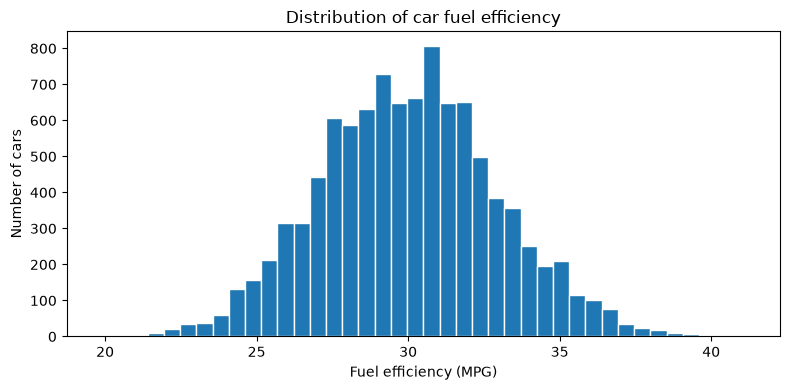

Skewness: 0.080804


count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df[target], bins=40, edgecolor="white")
ax.set(title="Distribution of car fuel efficiency", xlabel="Fuel efficiency (MPG)", ylabel="Number of cars")
fig.tight_layout()
plt.show()
print(f"Skewness: {df[target].skew():.6f}")
df[target].describe()

## Q1. Missing values

Check the selected columns before imputing anything.

In [4]:
missing_counts = df.isna().sum()
missing_counts

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

**Answer: `horsepower`** — 877 missing values. The other selected columns are complete.

## Q2. Median horsepower

Pandas excludes missing values when computing the median.

In [5]:
horsepower_median = df["horsepower"].median()
horsepower_median

np.float64(254.0)

**Answer: 254.**

## Split the data and implement linear regression

Use the exact shuffle and 60%/20%/20% split from the assignment. `RandomState`/`default_rng` are not substituted for the specified `np.random.seed` + `np.random.shuffle` sequence. The split contains 6,000 training, 2,000 validation, and 2,000 test rows.

The model follows the lectures: add an intercept column, then calculate
`w = (X.T @ X + r * I)^(-1) @ X.T @ y`.
As in the course implementation, regularization applies to every diagonal entry, including the intercept. With `r=0`, this is unregularized linear regression.

In [6]:
def split_data(df, seed=42):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].copy()
    df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
    df_test = df.iloc[idx[n_train + n_val:]].copy()
    return df_train, df_val, df_test


def prepare_X(frame, horsepower_fill=0):
    X = frame[features].copy()
    X["horsepower"] = X["horsepower"].fillna(horsepower_fill)
    return X.to_numpy(dtype=float)


def train_linear_regression(X, y, r=0.0):
    X = np.column_stack([np.ones(X.shape[0]), X])
    XTX = X.T @ X
    XTX = XTX + r * np.eye(XTX.shape[0])
    w = np.linalg.inv(XTX) @ X.T @ y
    return w[0], w[1:]


def rmse(y, y_pred):
    return np.sqrt(np.mean((y - y_pred) ** 2))


def evaluate(train, validation, horsepower_fill=0, r=0.0):
    X_train = prepare_X(train, horsepower_fill)
    y_train = train[target].to_numpy()
    w0, w = train_linear_regression(X_train, y_train, r=r)
    y_pred = w0 + prepare_X(validation, horsepower_fill) @ w
    return rmse(validation[target].to_numpy(), y_pred)


df_train, df_val, df_test = split_data(df, seed=42)
print({"train": len(df_train), "validation": len(df_val), "test": len(df_test)})

{'train': 6000, 'validation': 2000, 'test': 2000}


## Q3. Fill missing values with zero or the training mean

Compute the mean from the training subset only, and apply that same value to training and validation. Compare validation RMSE rounded to three decimals.

In [7]:
training_mean = df_train["horsepower"].mean()
print(f"Training mean horsepower: {training_mean:.6f}")
imputation_results = pd.DataFrame([
    {"fill": label, "rmse": evaluate(df_train, df_val, horsepower_fill=value)}
    for label, value in [("With 0", 0), ("With mean", training_mean)]
])
imputation_results["rmse_3dp"] = imputation_results["rmse"].map(lambda score: round(score, 3))
imputation_results

Training mean horsepower: 254.463383


,fill,rmse,rmse_3dp
0,With 0,2.205293,2.205
1,With mean,2.201817,2.202


**Answer: With mean.** Validation RMSE is **2.202**, compared with **2.205** for zero imputation. The improvement is small but remains visible at the required precision.

## Q4. Select regularization strength

Use zero imputation and the original seed-42 split. Rank the validation scores after rounding to four decimals; break ties by choosing the smallest `r`.

In [8]:
regularization_results = pd.DataFrame([
    {"r": r, "rmse": evaluate(df_train, df_val, horsepower_fill=0, r=r)}
    for r in [0, 0.01, 0.1, 1, 5, 10, 100]
])
regularization_results["rmse_4dp"] = regularization_results["rmse"].map(lambda score: round(score, 4))
best_r = regularization_results.sort_values(["rmse_4dp", "r"]).iloc[0]["r"]
print(f"Best r: {best_r:g}")
regularization_results

Best r: 0


,r,rmse,rmse_4dp
0,0.00,2.205293,2.2053
1,0.01,2.205828,2.2058
2,0.10,2.224143,2.2241
3,1.00,2.349229,2.3492
4,5.00,2.409380,2.4094
5,10.00,2.419470,2.4195
6,100.00,2.429202,2.4292


**Answer: 0.** Its validation RMSE rounds to **2.2053**; `r=0.01` gives **2.2058**. Larger values perform worse on this split.

## Q5. Sensitivity to the split seed

Repeat the split for seeds 0–9. Each model uses zero imputation and no regularization. Compute `np.std` on the unrounded validation scores, with its default `ddof=0`, then round the standard deviation to three decimals.

In [9]:
seed_scores = []
for seed in range(10):
    train, validation, _ = split_data(df, seed=seed)
    seed_scores.append({"seed": seed, "rmse": evaluate(train, validation)})

seed_results = pd.DataFrame(seed_scores)
rmse_std = np.std(seed_results["rmse"].to_numpy())
print(f"RMSE standard deviation: {rmse_std:.9f}")
print(f"Rounded: {round(rmse_std, 3)}")
seed_results

RMSE standard deviation: 0.028781274
Rounded: 0.029


,seed,rmse
0,0,2.239204
1,1,2.202113
2,2,2.163420
3,3,2.204359
4,4,2.201880
5,5,2.245785
6,6,2.269721
7,7,2.190795
8,8,2.216611
9,9,2.207037


**Answer: 0.029.** The unrounded standard deviation is approximately 0.028781.

## Q6. Final test evaluation

Split with seed 9, combine training and validation (8,000 rows), fill missing horsepower with zero, and fit with the explicitly required `r=0.001`. Evaluate on the 2,000 held-out test rows.

In [10]:
train, validation, test = split_data(df, seed=9)
full_train = pd.concat([train, validation], ignore_index=True)
test_rmse = evaluate(full_train, test, horsepower_fill=0, r=0.001)
print(f"Training rows: {len(full_train):,}; test rows: {len(test):,}")
print(f"Test RMSE: {test_rmse:.9f} MPG")
print(f"Rounded: {round(test_rmse, 3)}")

Training rows: 8,000; test rows: 2,000
Test RMSE: 2.235827747 MPG
Rounded: 2.236


**Answer: 2.236.** The unrounded test RMSE is approximately 2.235828 MPG.

## Answers for the submission form

| Question | Answer |
|---|---|
| 1. Missing values | `horsepower` |
| 2. Median horsepower | **254** |
| 3. Filling NAs | **With mean** |
| 4. Best regularization | **0** |
| 5. RMSE standard deviation | **0.029** |
| 6. Evaluation on test | **2.236** |

Submission form: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02